# Stimulus omission responses at different flash rates

This notebook generates the plots for Supplementary Figure 8 & 9 & 10, which showcases the omission stimulus responses of the model at different flash rates.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from retina import analysis, train

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")
osr_query_set = analysis.OSRQuerySet(root, ablate_recurrence=False)
osr_query_set_ablated = analysis.OSRQuerySet(root, ablate_recurrence=True)

In [3]:
def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax):
    # Intensity plot
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 20
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    intesity_ax.set_ylabel("Intensity", fontsize=fs, labelpad=35, rotation=0)
    
    # Firing rate plot
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)
    firing_ax.plot(ors_query.firing_rate[idx], linewidth=3) # 58
    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    firing_ax.set_ylim([0, max_r])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    
    firing_ax.set_yticks([0, max_r])
    firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)

## 16Hz OSR

In [4]:
ors_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16)

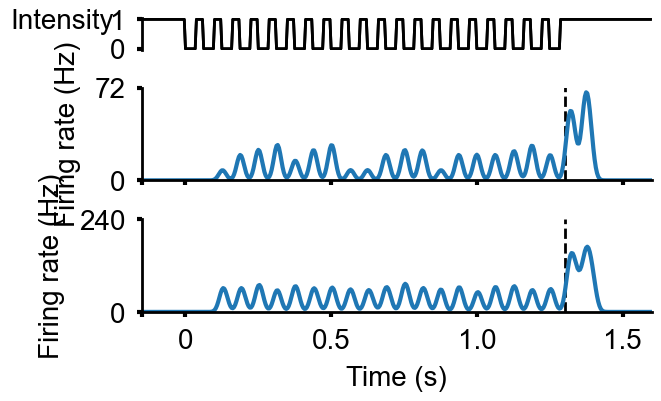

In [5]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_16hz, intesity_ax, 0.3, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_16hz, intesity_ax, 1, 58, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 8Hz OSR

In [6]:
ors_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8)

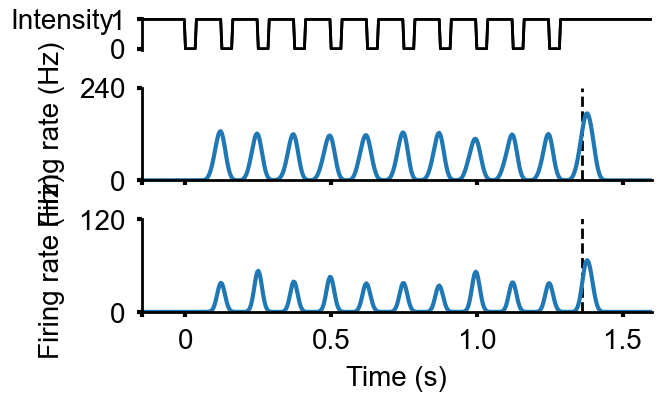

In [7]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-30+9+1+1
plot_osr(ors_query_8hz, intesity_ax, 1, ors_query_8hz.OSR_idx[2], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_8hz, intesity_ax, 0.5, ors_query_8hz.OSR_idx[0], d, firing2_ax)
plt.savefig(f"{root}/figures/supp/8hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 16 Hz with middle of the sequence omission

In [8]:
ors_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)

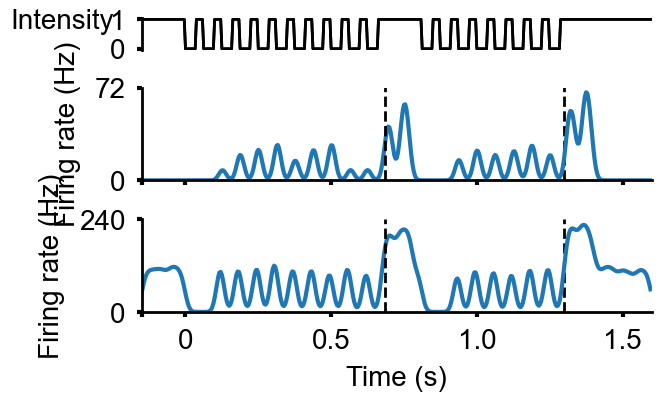

In [9]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1+1
x=200
plot_osr(ors_query_mid_16hz, intesity_ax, 0.3, ors_query_mid_16hz.OSR_idx[0], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_mid_16hz, intesity_ax, 1, ors_query_mid_16hz.OSR_idx[2], d, firing2_ax)
firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## Response latency to period relationship

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


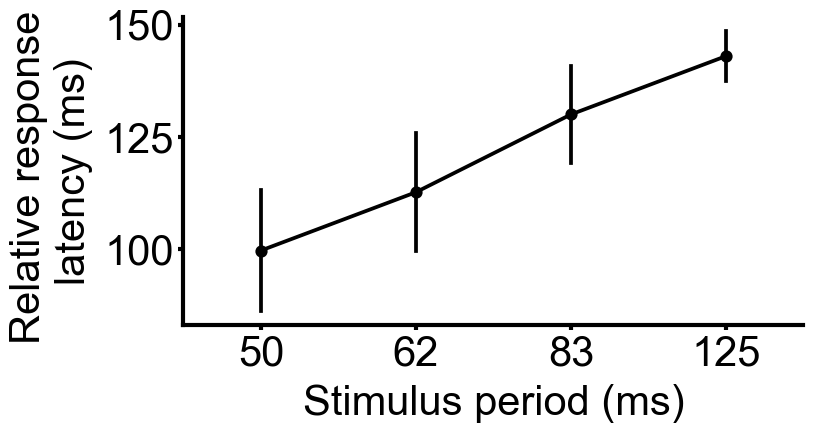

In [10]:
def plot_latency_vs_period(df, c, ax):
    sns.pointplot(df, x="period", y="latency", errorbar="se", estimator="median", c=c, ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Stimulus period (ms)", fontsize=30, labelpad=8)
    ax.set_ylabel("Relative response \nlatency (ms)", fontsize=30, labelpad=8)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_latency_vs_period(osr_query_set.get_latency_df(), "black", ax)
plt.savefig(f"{root}/figures/supp/rel_resp_lat.svg", format="svg", transparent=False, bbox_inches="tight")

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


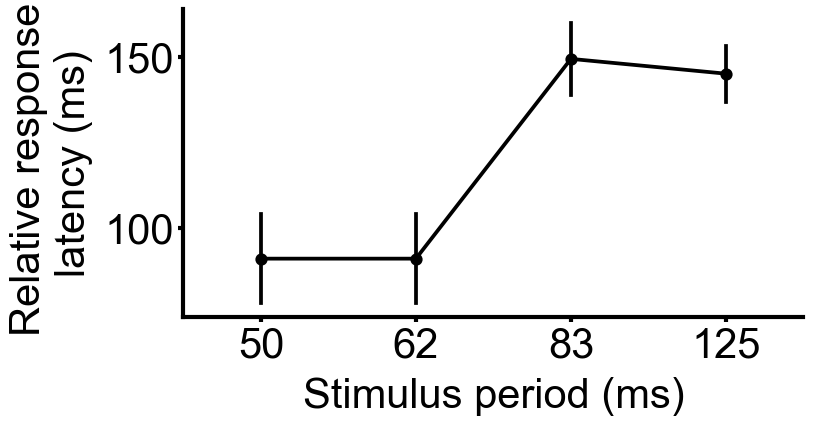

In [11]:
def plot_latency_vs_period(df, c, ax):
    sns.pointplot(df, x="period", y="latency", errorbar="se", estimator="median", c=c, ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Stimulus period (ms)", fontsize=30, labelpad=8)
    ax.set_ylabel("Relative response \nlatency (ms)", fontsize=30, labelpad=8)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_latency_vs_period(osr_query_set_ablated.get_latency_df(), "black", ax)
plt.savefig(f"{root}/figures/supp/rel_resp_lat_ablated.svg", format="svg", transparent=False, bbox_inches="tight")

## Inspection of spatiotemporal RFs of OSR units

In [19]:
ors_query = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300)

In [20]:
enc_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")
pred_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")
enc_rf_query = analysis.RFQuery(root, enc_model)
pred_rf_query = analysis.RFQuery(root, pred_model)

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 400
INFO:gaussian:Location criteria exclusion 40
INFO:gaussian:Envelope criteria exclusion 11
INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:CC criteria exclusion 218
INFO:gaussian:Location criteria exclusion 40
INFO:gaussian:Envelope criteria exclusion 11


In [23]:
def plot_spatiotemporal_rf(strf, i, subspec, fig):
    strf = strf.cpu().detach()
    maxv = strf.abs().max()
    
    for j in range(3, len(strf)):
        ax = plt.Subplot(fig, subspec[i, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="bwr", vmin=-maxv, vmax=maxv)
        ax.axis("off")

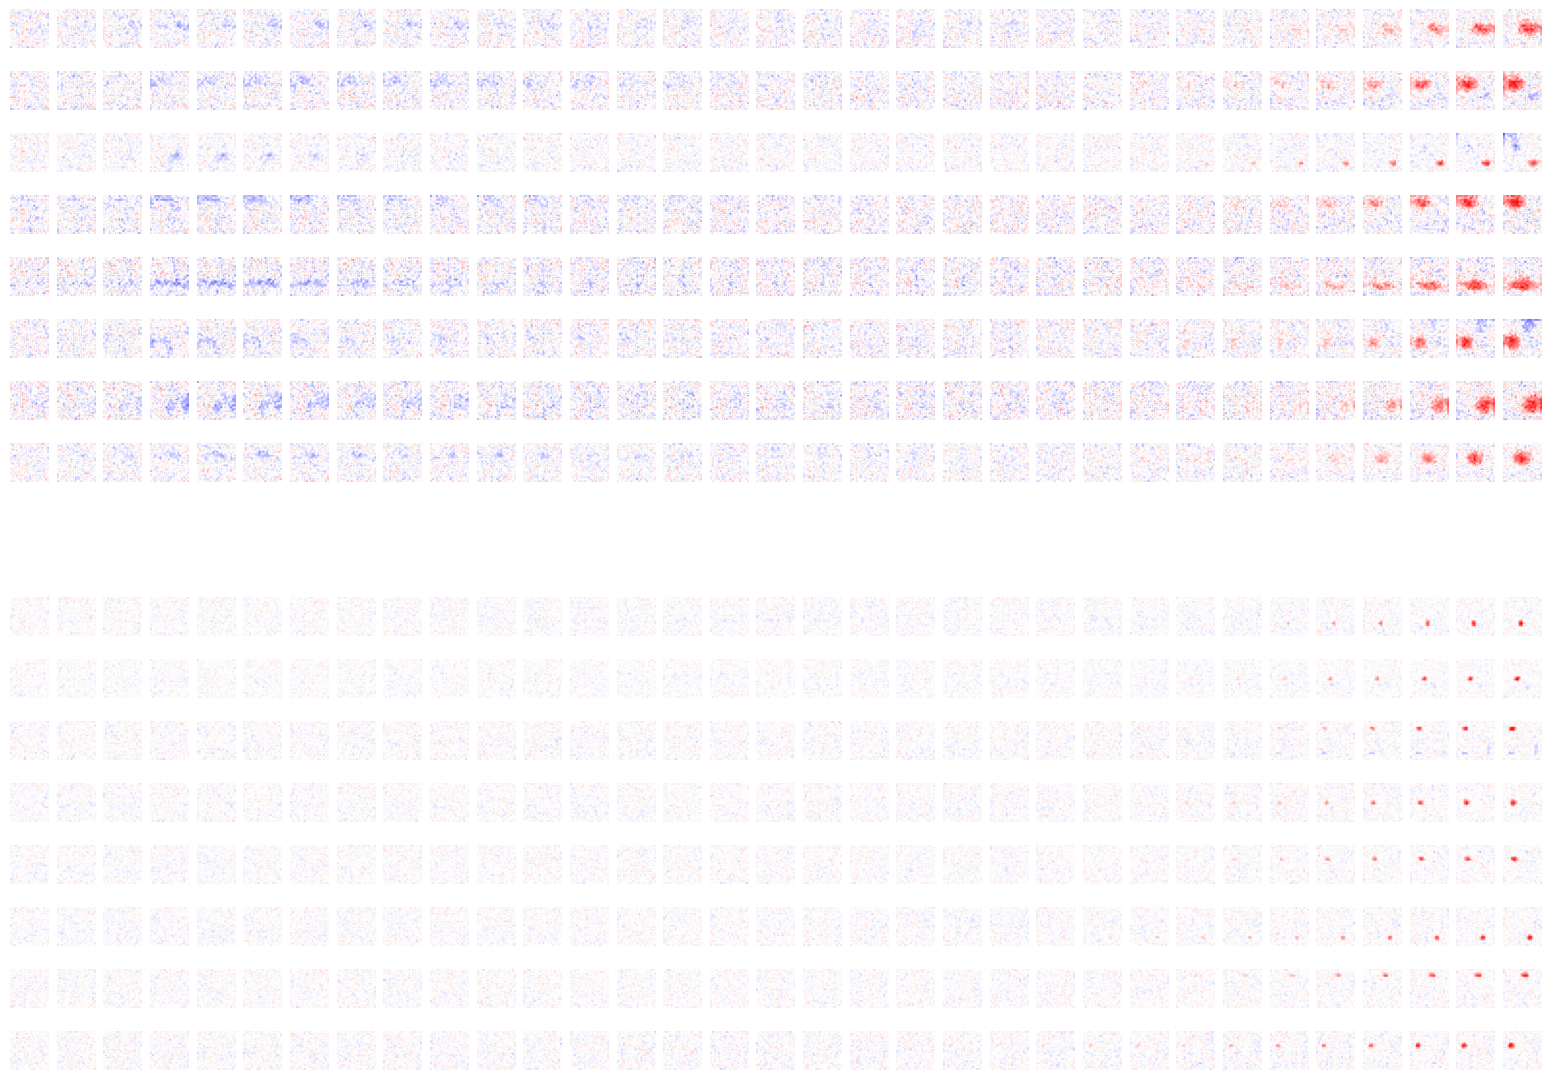

In [24]:
l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(8, 50, subplot_spec=spec[0], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(8, 50, subplot_spec=spec[1], hspace=0.1)

plot_spatiotemporal_rf(pred_rf_query.og_strfs[8, :], 0, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[17, :], 1, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[21, :], 2, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[29, :], 3, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[47, :], 4, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[79, :], 5, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[89, :], 6, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[178, :], 7, top_spec, fig)

plot_spatiotemporal_rf(enc_rf_query.og_strfs[2, :], 0, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[5, :], 1, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[35, :], 2, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[56, :], 3, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[70, :], 4, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[89, :], 5, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[127, :], 6, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[359, :], 7, bottom_spec, fig)